First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     

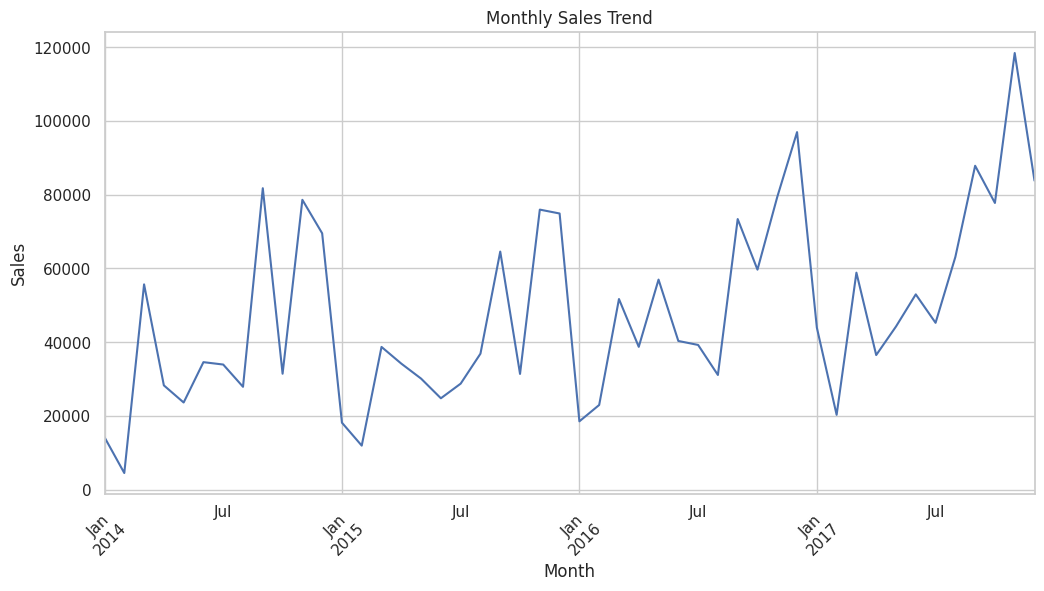

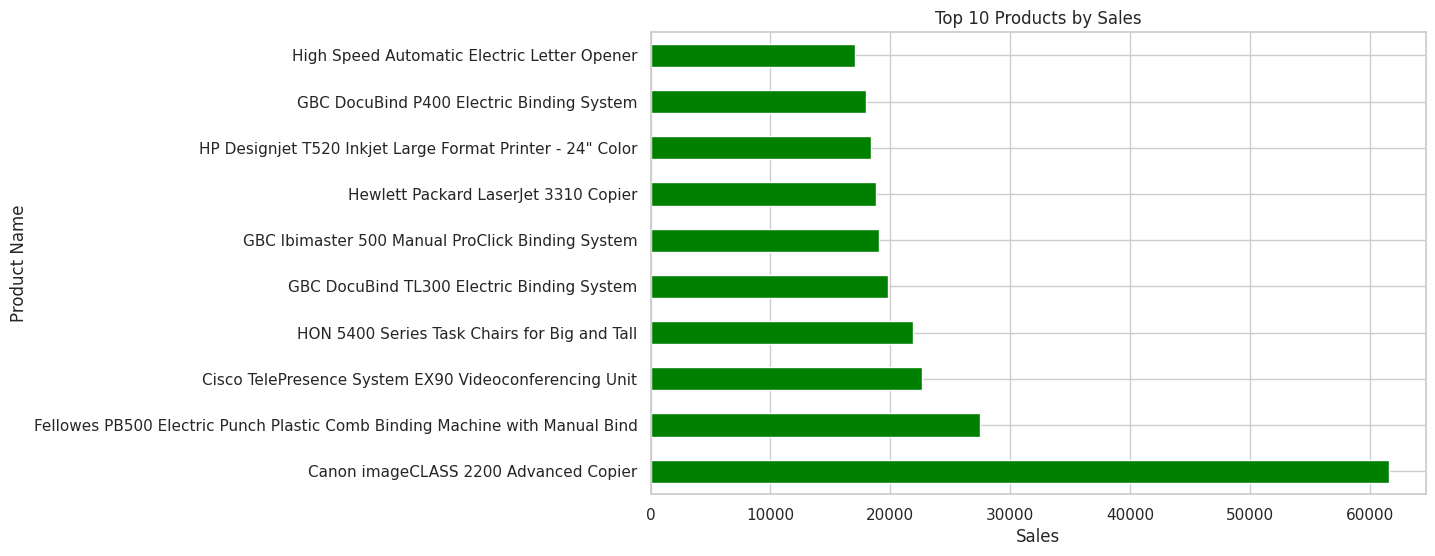

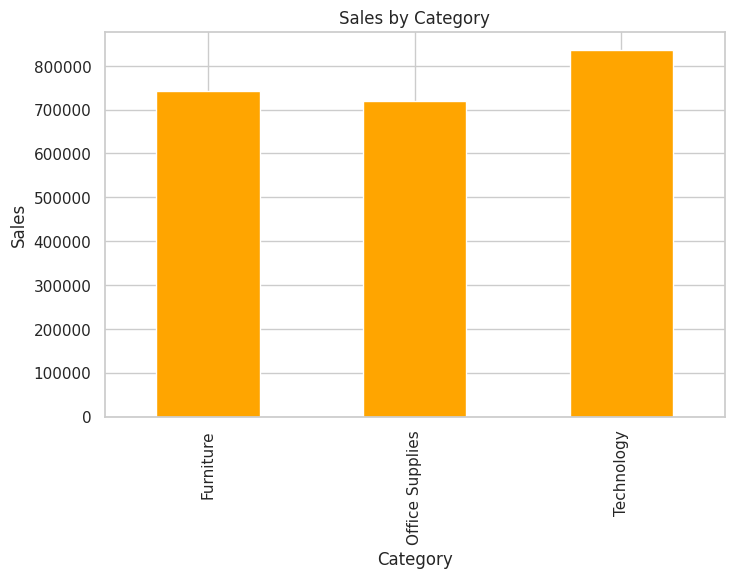

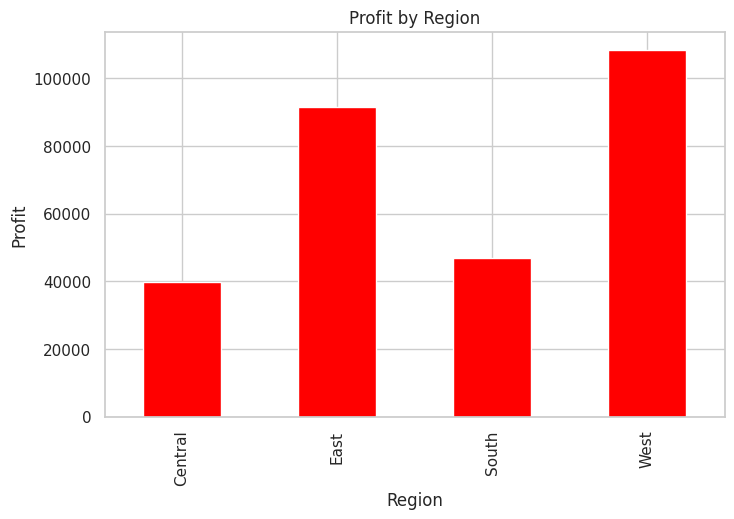

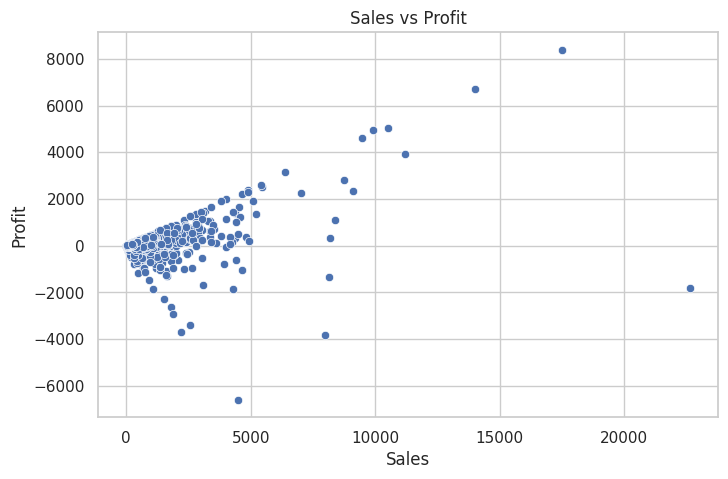


✅ Analysis Completed Successfully!
📊 Charts saved in /content/
📁 Cleaned dataset saved as cleaned_superstore.csv


In [9]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')
print("First 5 rows:")
print(df.head())
print("\nColumns in dataset:")
print(df.columns)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Profit Margin'] = df['Profit'] / df['Sales']
print("\nMissing values:")
print(df.isnull().sum())
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
profit_margin = total_profit / total_sales
print("\n===== KPI SUMMARY =====")
print(f"Total Sales: {total_sales}")
print(f"Total Profit: {total_profit}")
print(f"Total Orders: {total_orders}")
print(f"Overall Profit Margin: {profit_margin:.2f}")
sales_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(12,6))
sales_trend.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.savefig("/content/sales_trend.png")
plt.show()
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='green')
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.savefig("/content/top_products.png")
plt.show()
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='orange')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.savefig("/content/category_sales.png")
plt.show()
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar', color='red')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.savefig("/content/region_profit.png")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title("Sales vs Profit")
plt.savefig("/content/sales_vs_profit.png")
plt.show()
df.to_csv("/content/cleaned_superstore.csv", index=False)

print("\n✅ Analysis Completed Successfully!")
print("📊 Charts saved in /content/")
print("📁 Cleaned dataset saved as cleaned_superstore.csv")

In [10]:
from google.colab import files

files.download("/content/sales_trend.png")
files.download("/content/top_products.png")
files.download("/content/category_sales.png")
files.download("/content/region_profit.png")
files.download("/content/sales_vs_profit.png")
files.download("/content/cleaned_superstore.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

# Create a zip file of all outputs
shutil.make_archive("/content/project_files", 'zip', "/content")

# Download the zip
from google.colab import files
files.download("/content/project_files.zip")